In [20]:
import os
import random
import re
import shutil
from collections.abc import Callable, Sequence
from typing import Any, Literal
import math

import cv2
import lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rootutils
import segmentation_models_pytorch as smp
import torch
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as TF
from lightning import LightningDataModule, LightningModule
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from torchmetrics import Accuracy, ConfusionMatrix, F1Score, MaxMetric, MeanMetric
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.ops import masks_to_boxes
from torchvision.transforms import InterpolationMode
from torchvision.utils import save_image
from tqdm.notebook import tqdm

root = rootutils.setup_root(search_from=".", indicator=".project-root", pythonpath=True)

from src.data.components.dataset import FetalBrainPlanesDataset
from src.data.components.transforms import PadToAspectRation, Resize
from src.data.utils.utils import (
    read_image_tensor,
    save_image_tensor,
    show_pytorch_images,
)
from src.models.head_segmentation_module import HeadSegmentationLitModule

data_dir = root / "data"
dataset_name = "FETAL_BRAIN_PLANES_2"
dataset_dir = data_dir / dataset_name

# Create FETAL_BRAIN_PLANES dataset

## Create Dataset directory

In [ ]:
if not dataset_dir.exists():
    dataset_dir.mkdir(parents=True)
    print(f"Dataset directory '{dataset_name}' created successfully.")
else:
    print(f"Dataset directory '{dataset_name}' already exists.")

## Prepare csv

### Load FETAL_PLANE csv

In [41]:
fetal_planes = pd.read_csv(f"{data_dir}/FETAL_PLANES/data_fix.csv")
fetal_planes = fetal_planes[["Image_name", "Patient_num", "Brain_plane", "New_brain_plane", "Train", "Subset", "Duplicate", "Valid"]]
fetal_planes = fetal_planes.reset_index(drop=True)
fetal_planes

,Image_name,Patient_num,Brain_plane,New_brain_plane,Train,Subset,Duplicate,Valid
0,Patient00001_Plane1_1_of_15,1,Not A Brain,NaN,1,train,NaN,1
1,Patient00001_Plane1_2_of_15,1,Not A Brain,NaN,1,train,NaN,1
2,Patient00001_Plane1_3_of_15,1,Not A Brain,NaN,1,train,NaN,1
3,Patient00001_Plane1_4_of_15,1,Not A Brain,NaN,1,train,NaN,1
4,Patient00001_Plane1_5_of_15,1,Not A Brain,NaN,1,train,NaN,1
...,...,...,...,...,...,...,...,...
12395,Patient01791_Plane5_1_of_1,1791,Not A Brain,NaN,0,test,NaN,1
12396,Patient01792_Plane2_1_of_1,1792,Not A Brain,NaN,0,test,NaN,1
12397,Patient01792_Plane3_1_of_1,1792,Trans-thalamic,NaN,0,test,NaN,1
12398,Patient01792_Plane5_1_of_1,1792,Not A Brain,NaN,0,test,NaN,1


In [42]:
invalid_images = 0
other_images = 0

for index, row in tqdm(fetal_planes.iterrows(), total=len(fetal_planes)):
    if not np.isnan(row["Duplicate"]) or row["Valid"] != 1 or isinstance(row["New_brain_plane"], str):
        fetal_planes.loc[index, "Valid"] = 0
        invalid_images += 1

    if row["Brain_plane"] == "Other":
        fetal_planes.loc[index, "Brain_plane"] = "Not A Brain"
        other_images += 1

fetal_planes = fetal_planes.drop(['New_brain_plane', 'Duplicate'], axis=1)

print(f"Images: {len(fetal_planes)}")
print(f"Invalid images: {invalid_images}")
print(f"Other images: {other_images}")
fetal_planes

  0%|          | 0/12400 [00:00<?, ?it/s]

Images: 12400
Invalid images: 1083
Other images: 143


,Image_name,Patient_num,Brain_plane,Train,Subset,Valid
0,Patient00001_Plane1_1_of_15,1,Not A Brain,1,train,1
1,Patient00001_Plane1_2_of_15,1,Not A Brain,1,train,1
2,Patient00001_Plane1_3_of_15,1,Not A Brain,1,train,1
3,Patient00001_Plane1_4_of_15,1,Not A Brain,1,train,1
4,Patient00001_Plane1_5_of_15,1,Not A Brain,1,train,1
...,...,...,...,...,...,...
12395,Patient01791_Plane5_1_of_1,1791,Not A Brain,0,test,1
12396,Patient01792_Plane2_1_of_1,1792,Not A Brain,0,test,1
12397,Patient01792_Plane3_1_of_1,1792,Trans-thalamic,0,test,1
12398,Patient01792_Plane5_1_of_1,1792,Not A Brain,0,test,1


### Assign Subset value (the same as for other experiments)

In [ ]:
train_fetal_planes = fetal_planes[fetal_planes["Train"] == 1].reset_index(drop=True)

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=5724)
split = splitter.split(list(range(len(train_fetal_planes))), groups=train_fetal_planes["Patient_num"])
train_idx, val_idx = next(split)

fetal_planes["Subset"] = "test"

for idx, image_name in tqdm(
    enumerate(train_fetal_planes["Image_name"]), total=len(train_fetal_planes), desc="Add subset value"
):
    if idx in val_idx:
        subset = "val"
    else:
        subset = "train"
    fetal_planes.loc[fetal_planes["Image_name"] == image_name, "Subset"] = subset

fetal_planes

### Statistics

In [ ]:
fetal_planes["Subset"].value_counts()

In [ ]:
fetal_planes["Plane"].value_counts()

In [43]:
fetal_planes["Brain_plane"].value_counts()

Brain_plane
Not A Brain          9451
Trans-thalamic       1638
Trans-cerebellum      714
Trans-ventricular     597
Name: count, dtype: int64

In [ ]:
fetal_planes[fetal_planes["Plane"] == "Fetal brain"]["Subset"].value_counts()

### Validate Subset on FetalBrainPlanesDataset

In [ ]:
train = FetalBrainPlanesDataset(
    data_dir=data_dir,
    train=True,
)

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=5724)
split = splitter.split(train, groups=train.img_labels["Patient_num"])
train_idx, val_idx = next(split)

train_df = train.img_labels.iloc[train_idx]
val_df = train.img_labels.iloc[val_idx]


incorrect = 0
for index, row in tqdm(fetal_planes.iterrows(), total=len(fetal_planes)):
    image_name = row["Image_name"]
    subset = row["Subset"]
    subset_train = train_df[train_df["Image_name"] == image_name]
    subset_val = val_df[val_df["Image_name"] == image_name]

    if subset == "train" and len(subset_train) != 1:
        incorrect += 1
    elif subset == "val" and len(subset_val) != 1:
        incorrect += 1

print(f"incorrect: {incorrect}")

### Validate Subset on fetal_head_segmentation

In [ ]:
fetal_head_segmentation = pd.read_csv(f"{data_dir}/FETAL_HEAD_SEGMENTATION/data.csv")
fetal_head_segmentation

incorrect = 0
for index, row in tqdm(fetal_planes.iterrows(), total=len(fetal_planes)):
    image_name = row["Image_name"]
    subset = row["Subset"]
    subset_2 = list(fetal_head_segmentation[fetal_head_segmentation["Image_name"] == image_name]["Subset"])
    if len(subset_2) == 1 and subset_2[0] != subset:
        incorrect += 1
        print(f"Error: {index} {row}")
        print(f"subset_2: {subset_2}")
        print()
        break

print(f"incorrect: {incorrect}")

### Save csv

In [44]:
fetal_planes.to_csv(dataset_dir / "data.csv", index=False)
fetal_planes

,Image_name,Patient_num,Brain_plane,Train,Subset,Valid
0,Patient00001_Plane1_1_of_15,1,Not A Brain,1,train,1
1,Patient00001_Plane1_2_of_15,1,Not A Brain,1,train,1
2,Patient00001_Plane1_3_of_15,1,Not A Brain,1,train,1
3,Patient00001_Plane1_4_of_15,1,Not A Brain,1,train,1
4,Patient00001_Plane1_5_of_15,1,Not A Brain,1,train,1
...,...,...,...,...,...,...
12395,Patient01791_Plane5_1_of_1,1791,Not A Brain,0,test,1
12396,Patient01792_Plane2_1_of_1,1792,Not A Brain,0,test,1
12397,Patient01792_Plane3_1_of_1,1792,Trans-thalamic,0,test,1
12398,Patient01792_Plane5_1_of_1,1792,Not A Brain,0,test,1


##  Prepare Data

### Delete Dataset Image directory

In [ ]:
images_dir = dataset_dir / "Images"

if images_dir.exists():
    shutil.rmtree(images_dir)
    print(f"Directory '{images_dir}' and all its contents have been removed.")
else:
    print(f"Directory '{images_dir}' does not exist.")

### Create Dataset Images directory

In [ ]:
images_dir = dataset_dir / "Images"

if not images_dir.exists():
    shutil.copytree(f"{data_dir}/FETAL_PLANES/Images", images_dir)
    print(f"{images_dir.stem} directory created successfully.")
else:
    print(f"{images_dir.stem} directory already exists.")

### Process images

In [ ]:
def find_angle(mask):
    mask = mask.squeeze(0)

    # Get the indices of the non-zero elements
    coords = torch.nonzero(mask, as_tuple=False).float()
    # Center the data by subtracting the mean
    mean = torch.mean(coords, dim=0)
    centered_coords = coords - mean

    # Calculate the covariance matrix
    covariance_matrix = torch.matmul(centered_coords.T, centered_coords)
    # Perform eigenvalue decomposition to find eigenvectors (principal components)
    eigenvalues, eigenvectors = torch.linalg.eigh(covariance_matrix)
    # The eigenvector corresponding to the largest eigenvalue (the first principal component)
    principal_axis = eigenvectors[:, 1]
    # Calculate the angle of the principal axis
    angle = torch.atan2(principal_axis[0], principal_axis[1]) * 180 / torch.pi

    return angle.round().int()


def crop(image, x1, y1, x2, y2, pad=10):

    pad_x = int((x2 - x1) * (pad / 100.0))
    left_pad = pad_x // 2
    right_pad = pad_x - left_pad

    pad_y = int((y2 - y1) * (pad / 100.0))
    top_pad = pad_y // 2
    bottom_pad = pad_y - top_pad

    x1 = max(x1 - left_pad, 0)
    y1 = max(y1 - top_pad, 0)
    x2 = min(x2 + right_pad, image.shape[2])
    y2 = min(y2 + bottom_pad, image.shape[1])
    return TF.crop(image, y1, x1, y2 - y1, x2 - x1)


def add_half(center, radius):
    if torch.isclose(center, torch.round(center)):
        if torch.isclose(radius, torch.round(radius)):
            radius = radius + 0.5
    else: 
        if not torch.isclose(radius, torch.round(radius)):
            radius = radius + 0.5
    return radius
    

def create_ellipse_tensor(
    height: int, width: int, 
    center_x: int, center_y: int, 
    radius_x: int, radius_y: int,
) -> torch.Tensor:
    """
    Creates a 2D PyTorch tensor with a binary ellipse shape.

    Args:
        height (int): The height of the tensor.
        width (int): The width of the tensor.
        center_x (int): The x-coordinate of the ellipse's center.
        center_y (int): The y-coordinate of the ellipse's center.
        radius_x (int): The radius of the ellipse along the x-axis.
        radius_y (int): The radius of the ellipse along the y-axis.

    Returns:
        torch.Tensor: A 2D tensor of shape (height, width) with 1s inside the
                      ellipse and 0s outside.
    """
    radius_x = add_half(center_x, radius_x)
    radius_y = add_half(center_y, radius_y)
    
    y, x = torch.meshgrid(torch.arange(height), torch.arange(width), indexing='ij')
    x_translated = x - center_x
    y_translated = y - center_y
    ellipse_mask = (x_translated / radius_x)**2 + (y_translated / radius_y)**2 <= 1
    ellipse_tensor = ellipse_mask.float()
    return ellipse_tensor


def get_dice_score(inputs: torch.Tensor, targets: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:
    inputs = inputs.contiguous().view(-1)
    targets = targets.contiguous().view(-1)

    intersection = (inputs * targets).sum()
    dice_score = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
    return dice_score


def overlap_mask(image: torch.Tensor, mask: torch.Tensor):
    image = image.clone()
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)
    if image.max() <= 1.0:
        image = image * 255

    image = image.int()
    image[0] = image[0] + mask * 255 * 0.4
    image = torch.clamp(image, min=0, max=255)
    image = image.to(torch.uint8)

    return image


image_size = (192, 256)
transform = torch.nn.Sequential(
    T.Grayscale(),
    PadToAspectRation(image_size, fill=0),
    # Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
    Resize(image_size, interpolation=T.InterpolationMode.NEAREST),
    T.ToDtype(torch.float32, scale=True),
)
pad_to_aspect_ration = PadToAspectRation(image_size, fill=0)

In [45]:
images_dir = dataset_dir / "Images"

segmentation = pd.read_csv(data_dir / "FETAL_HEAD_SEGMENTATION_2" / "data.csv", dtype={"Patient_num": str})
fetal_planes = pd.read_csv(f"{dataset_dir}/data.csv")
fetal_planes

,Image_name,Patient_num,Brain_plane,Train,Subset,Valid
0,Patient00001_Plane1_1_of_15,1,Not A Brain,1,train,1
1,Patient00001_Plane1_2_of_15,1,Not A Brain,1,train,1
2,Patient00001_Plane1_3_of_15,1,Not A Brain,1,train,1
3,Patient00001_Plane1_4_of_15,1,Not A Brain,1,train,1
4,Patient00001_Plane1_5_of_15,1,Not A Brain,1,train,1
...,...,...,...,...,...,...
12395,Patient01791_Plane5_1_of_1,1791,Not A Brain,0,test,1
12396,Patient01792_Plane2_1_of_1,1792,Not A Brain,0,test,1
12397,Patient01792_Plane3_1_of_1,1792,Trans-thalamic,0,test,1
12398,Patient01792_Plane5_1_of_1,1792,Not A Brain,0,test,1


In [46]:
def read_mask_tensor(mask_path):
    img_path = data_dir / "FETAL_HEAD_SEGMENTATION_2" / mask_path
    image = read_image_tensor(img_path)
    image = image[:1, :, :]  # single-channel for mask
    image = image // 255
    return image


if 'Image_crop_name' not in fetal_planes.columns:
    fetal_planes.insert(1, 'Image_crop_name', "")
else:
    fetal_planes['Image_crop_name'] = ""


brain_planes = fetal_planes[fetal_planes["Brain_plane"] != "Not A Brain"]
for index, row in tqdm(brain_planes.iterrows(), total=len(brain_planes), desc="Process images"):
    for _, segmentation_row  in segmentation[segmentation["Image_name"] == row["Image_name"]].iterrows():
        image_name = row["Image_name"]
        image_path = images_dir / f"{image_name}.png"
        image = read_image_tensor(image_path)
        image = pad_to_aspect_ration(image)

        mask_path = segmentation_row["Segmentation_path"]
        mask = read_mask_tensor(mask_path)

        angle = find_angle(mask)
        mask = TF.resize(mask, size=image.shape[1:], interpolation=T.InterpolationMode.NEAREST)            
        mask = TF.rotate(mask, angle=angle, expand=True, interpolation=T.InterpolationMode.NEAREST)
        image = TF.rotate(image, angle=angle, expand=True, interpolation=T.InterpolationMode.BILINEAR)

        x1, y1, x2, y2 = masks_to_boxes(mask)[0].int()
        image = crop(image, x1, y1, x2, y2, pad=5)
        
        output_path = dataset_dir / "Images" / f"{image_name}_crop.png"
        save_image_tensor(image, output_path)
        fetal_planes.loc[index, 'Image_crop_name'] = output_path.stem

fetal_planes

Process images:   0%|          | 0/2949 [00:00<?, ?it/s]

,Image_name,Image_crop_name,Patient_num,Brain_plane,Train,Subset,Valid
0,Patient00001_Plane1_1_of_15,,1,Not A Brain,1,train,1
1,Patient00001_Plane1_2_of_15,,1,Not A Brain,1,train,1
2,Patient00001_Plane1_3_of_15,,1,Not A Brain,1,train,1
3,Patient00001_Plane1_4_of_15,,1,Not A Brain,1,train,1
4,Patient00001_Plane1_5_of_15,,1,Not A Brain,1,train,1
...,...,...,...,...,...,...,...
12395,Patient01791_Plane5_1_of_1,,1791,Not A Brain,0,test,1
12396,Patient01792_Plane2_1_of_1,,1792,Not A Brain,0,test,1
12397,Patient01792_Plane3_1_of_1,Patient01792_Plane3_1_of_1_crop,1792,Trans-thalamic,0,test,1
12398,Patient01792_Plane5_1_of_1,,1792,Not A Brain,0,test,1


In [49]:
fetal_planes.to_csv(dataset_dir / "data.csv", index=False)
fetal_planes

,Image_name,Image_crop_name,Patient_num,Brain_plane,Train,Subset,Valid
0,Patient00001_Plane1_1_of_15,,1,Not A Brain,1,train,1
1,Patient00001_Plane1_2_of_15,,1,Not A Brain,1,train,1
2,Patient00001_Plane1_3_of_15,,1,Not A Brain,1,train,1
3,Patient00001_Plane1_4_of_15,,1,Not A Brain,1,train,1
4,Patient00001_Plane1_5_of_15,,1,Not A Brain,1,train,1
...,...,...,...,...,...,...,...
12395,Patient01791_Plane5_1_of_1,,1791,Not A Brain,0,test,1
12396,Patient01792_Plane2_1_of_1,,1792,Not A Brain,0,test,1
12397,Patient01792_Plane3_1_of_1,Patient01792_Plane3_1_of_1_crop,1792,Trans-thalamic,0,test,1
12398,Patient01792_Plane5_1_of_1,,1792,Not A Brain,0,test,1


In [55]:
checkpoint_file = root / "logs" / "head_segmentation_train" / "runs" / "2025-08-25_13-36-03" # cerulean-wave-694 42/8 - best
checkpoint = sorted(checkpoint_file.glob("checkpoints/epoch_*.ckpt"))[-1]
model = HeadSegmentationLitModule.load_from_checkpoint(str(checkpoint))
# disable randomness, dropout, etc...
model.eval()
model.to("cpu")
print("Loaded")

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Loaded


#### Test segmentation model

In [56]:
head_segmentation = pd.read_csv(f"{data_dir}/FETAL_HEAD_SEGMENTATION_2/data.csv")
fetal_planes = pd.read_csv(f"{dataset_dir}/data.csv")

brain_images = []
brain_high_score_images = []
brain_low_score_images = []
unidentified_images = []
misidentified_images = []
for index, plane_row in tqdm(fetal_planes.iterrows(), total=len(fetal_planes), desc="Porcess images"):
    for _, row  in head_segmentation[head_segmentation["Image_name"] == plane_row["Image_name"]].iterrows():
        if row["Valid"] != 1:
            continue
    
        is_brain_plane = row["Brain_plane"] == 1
        image_name = row["Image_name"]
        image_path = images_dir / f"{image_name}.png"
        image = read_image_tensor(image_path)
            
        with torch.no_grad():
            brain_plane = transform(image)
            logits = model(brain_plane.unsqueeze(0))
            _, prediction_labels = model.calculate_prediction(logits)
            prediction_label = prediction_labels.squeeze(0)
            
            if prediction_label == 1:
                brain_plane = pad_to_aspect_ration(image)
                angle = find_angle(prediction)
                prediction = TF.resize(prediction, size=brain_plane.shape[1:], interpolation=T.InterpolationMode.NEAREST)
                brain_plane = overlap_mask(brain_plane, prediction)
                
                prediction = TF.rotate(prediction, angle=angle, expand=True, interpolation=T.InterpolationMode.NEAREST)
        
                x1, y1, x2, y2 = masks_to_boxes(prediction)[0].int()
                perfect_mask = create_ellipse_tensor(
                    prediction.shape[1], 
                    prediction.shape[2],
                    x1 + ((x2-x1)/2),
                    y1 + ((y2-y1)/2),
                    (x2-x1)/2,
                    (y2-y1)/2,
                )
                dice_score = get_dice_score(prediction, perfect_mask)
                
    
                if is_brain_plane:
                    brain_images.append((index, brain_plane))
                    
                    if dice_score > 0.95:
                        brain_high_score_images.append((index, brain_plane))
                    else:
                        brain_low_score_images.append((index, brain_plane))
                    
                else:
                    misidentified_images.append((index, brain_plane))
            else:
                if is_brain_plane:
                    unidentified_images.append((index, image))


print(f"Number of brain images {len(brain_images)}")
print(f"Number of high score brain images {len(brain_high_score_images)}")
print(f"Number of low score brain images {len(brain_low_score_images)}")
print(f"Number of unidentified images {len(unidentified_images)}")
print(f"Number of misidentified images {len(misidentified_images)}")

Porcess images:   0%|          | 0/12400 [00:00<?, ?it/s]

Number of brain images 2991
Number of high score brain images 2973
Number of low score brain images 18
Number of unidentified images 16
Number of misidentified images 11


Random brain images

In [ ]:
images = []
for rand_i in torch.randperm(len(brain_images))[:64]:
    i, image = brain_images[rand_i]
    image_name = fetal_planes.Image_name[i]
    plane = fetal_planes.Plane[i]
    brain_plane = fetal_planes.Brain_plane[i]
    subset = fetal_planes.Subset[i]
    images.append((image, f"Brain_{brain_plane} - {subset}"))

if images:
    show_pytorch_images(images, gray=False).show()

Low score brain images

In [ ]:
images = []
for i, image in brain_low_score_images:
    image_name = fetal_planes.Image_name[i]
    image_path = images_dir / f"{image_name}.png"
    image_original = read_image_tensor(image_path)
    image_original = pad_to_aspect_ration(image_original)
    plane = fetal_planes.Plane[i]
    brain_plane = fetal_planes.Brain_plane[i]
    subset = fetal_planes.Subset[i]
    images.append((image_original, f"{i}:{brain_plane}"))
    images.append(image)

if images:
    show_pytorch_images(images, gray=False).show()

Unidentified brain images

1828: Patient00660_Plane3_1_of_1
1888: Patient00684_Plane1_1_of_1
2574: Patient00759_Plane3_2_of_4
2876: Patient00782_Plane3_3_of_4
3048: Patient00790_Plane1_19_of_47
3407: Patient00803_Plane3_1_of_5
3474: Patient00807_Plane3_4_of_5
4993: Patient00914_Plane3_3_of_4
5842: Patient01022_Plane3_1_of_5
7449: Patient01221_Plane1_6_of_9
8111: Patient01298_Plane3_6_of_9
8553: Patient01346_Plane3_3_of_3
9380: Patient01444_Plane3_7_of_7
9891: Patient01486_Plane1_13_of_26
10741: Patient01571_Plane3_1_of_1
11054: Patient01612_Plane3_1_of_3


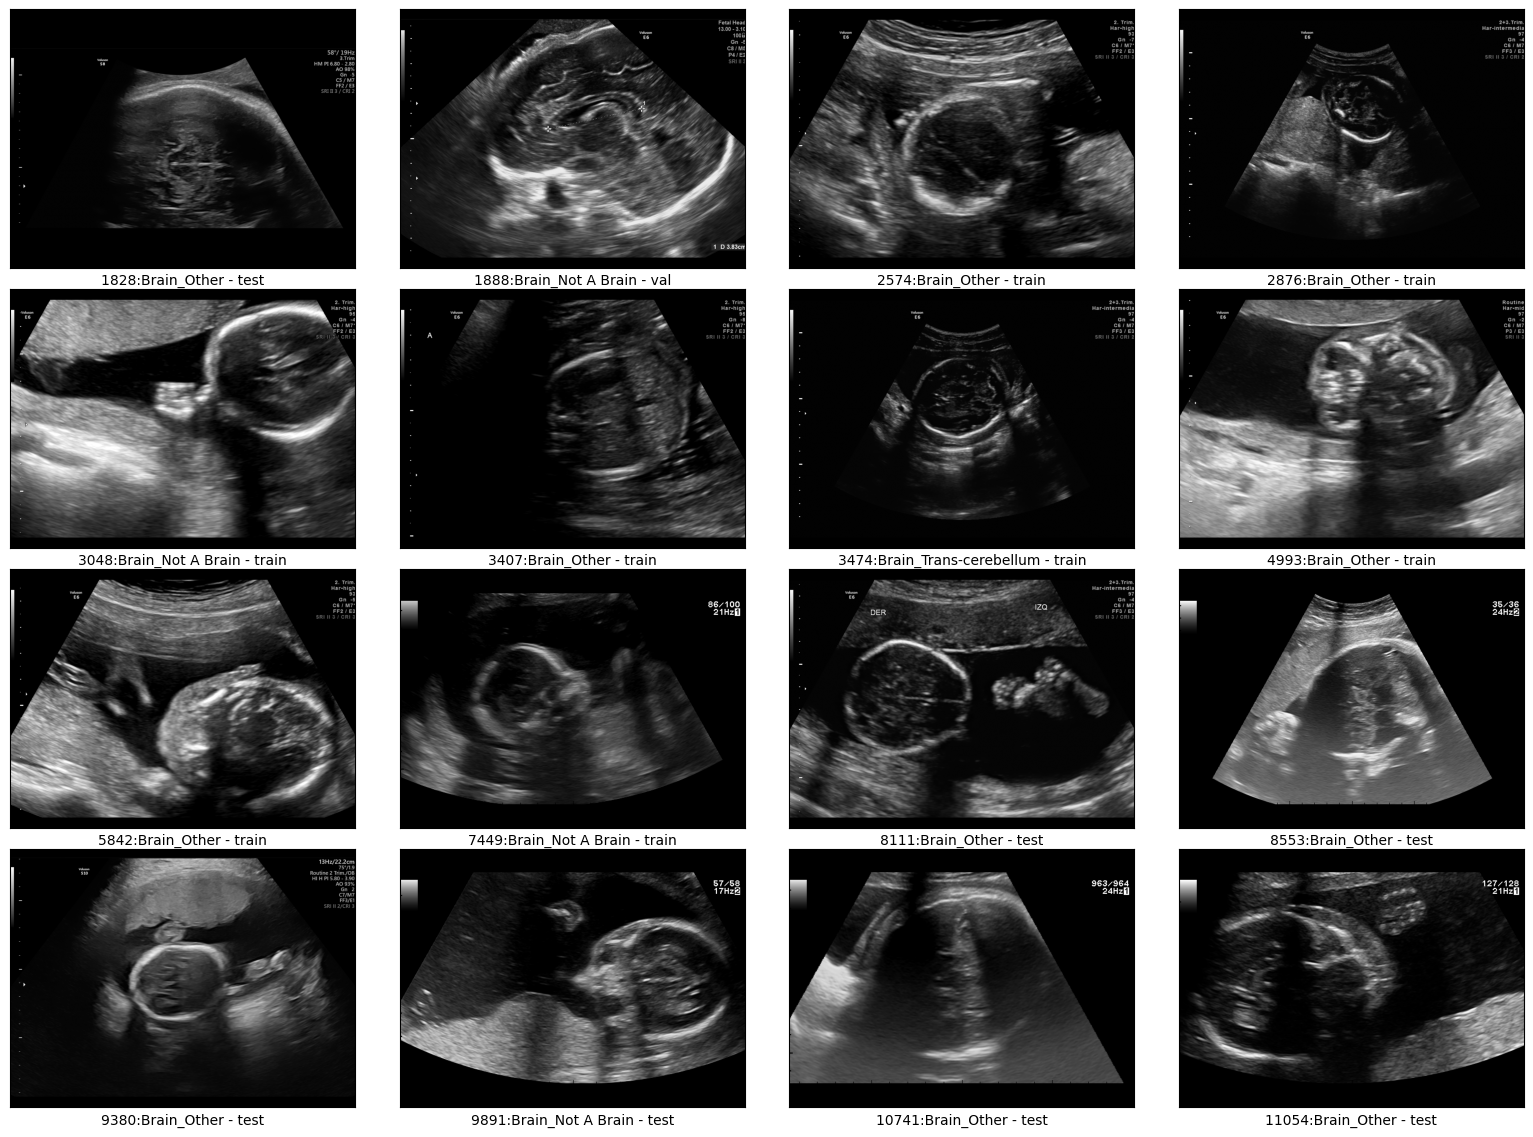

In [58]:
images = []
for i, image in unidentified_images:
    image = pad_to_aspect_ration(image)
    image_name = fetal_planes.Image_name[i]
    plane = fetal_planes.Plane[i]
    brain_plane = fetal_planes.Brain_plane[i]
    subset = fetal_planes.Subset[i]
    images.append((image, f"{i}:Brain_{brain_plane} - {subset}"))
    print(f"{i}: {image_name}")

if images:
    show_pytorch_images(images).show()

Not a brain images identify as brain image

"Patient00168_Plane1_10_of_23",
"Patient00829_Plane4_2_of_3",
"Patient00829_Plane4_3_of_3",
"Patient00961_Plane1_1_of_1",
"Patient01003_Plane1_1_of_1",
"Patient01036_Plane1_1_of_1",
"Patient01149_Plane1_1_of_1",
"Patient01286_Plane1_1_of_1",
"Patient01325_Plane4_6_of_6",
"Patient01487_Plane6_1_of_1",
"Patient01547_Plane1_1_of_18",


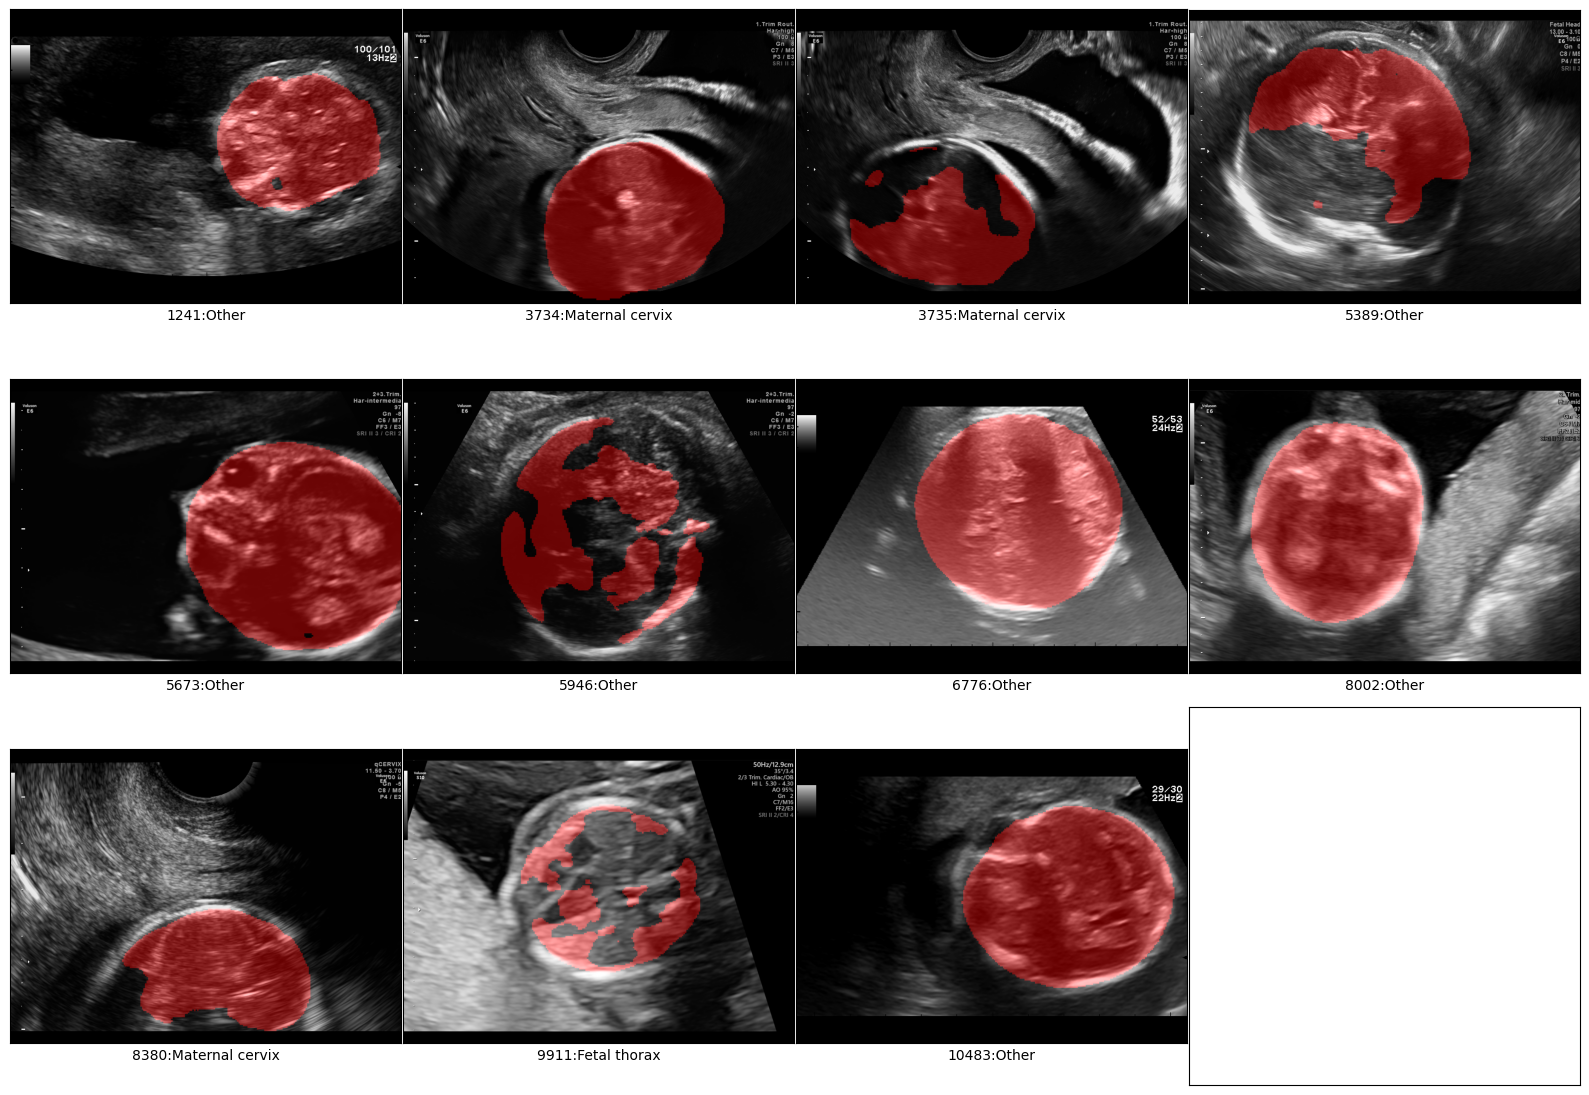

In [57]:
images = []
for i, image in misidentified_images:
    image_name = fetal_planes.Image_name[i]
    plane = fetal_planes.Plane[i]
    brain_plane = fetal_planes.Brain_plane[i]
    subset = fetal_planes.Subset[i]
    images.append((image, f"{i}:{plane}"))
    print(f"\"{image_name}\",")

if images:
    show_pytorch_images(images, gray=False).show()

Score for Not a brain images identify as brain image

In [ ]:
score_00_images = []
score_95_images = []
for i, _ in misidentified_images:
    plane = fetal_planes.Plane[i]
    image_name = fetal_planes.Image_name[i]
    image_path = images_dir / f"{image_name}.png"
    image = read_image_tensor(image_path)
        
    with torch.no_grad():
        brain_plane = transform(image)
        logits = model(brain_plane.unsqueeze(0)).squeeze(0)
        prediction = (torch.sigmoid(logits) > 0.5).int()

        ones_counts = prediction.sum()
        total_pixels = prediction.numel()
        ones_percent = ones_counts.float() / total_pixels
        prediction_label = (ones_percent >= 0.05).int()
        
        brain_plane = pad_to_aspect_ration(image)
        angle = find_angle(prediction)
        prediction = TF.resize(prediction, size=brain_plane.shape[1:], interpolation=T.InterpolationMode.NEAREST)
        brain_plane = overlap_mask(brain_plane, prediction)
        
        prediction = TF.rotate(prediction, angle=angle, interpolation=T.InterpolationMode.NEAREST)

        x1, y1, x2, y2 = masks_to_boxes(prediction)[0].int()
        perfect_mask = create_ellipse_tensor(
            prediction.shape[1], 
            prediction.shape[2],
            x1 + ((x2-x1)/2),
            y1 + ((y2-y1)/2),
            (x2-x1)/2,
            (y2-y1)/2,
        )
        dice_score = get_dice_score(prediction, perfect_mask)
        
        if dice_score > 0.95:
            score_95_images.append((brain_plane, f"{dice_score.item():.3f}"))
        else:
            score_00_images.append((image, f"{i}:{plane}"))
            score_00_images.append((brain_plane, f"{dice_score.item():.3f}"))

print(f"Number of 0.00 {len(score_00_images) // 2}/{len(misidentified_images)}")
print(f"Number of 0.95 {len(score_95_images)}/{len(misidentified_images)}")

if score_00_images:
    show_pytorch_images(score_00_images, gray=False).show()
if score_95_images:
    show_pytorch_images(score_95_images, gray=False).show()

#### Crop images

In [ ]:
fetal_planes = pd.read_csv(dataset_dir / "data.csv")

if 'Image_crop_name' not in fetal_planes.columns:
    fetal_planes.insert(1, 'Image_crop_name', "")
else:
    fetal_planes['Image_crop_name'] = ""

brain_images = []
unidentified_images = []
misidentified_images = []

for index, row in tqdm(fetal_planes.iterrows(), total=len(fetal_planes), desc="Porcess images"):
    plane = row["Plane"]
    image_name = row["Image_name"]
    image_path = images_dir / f"{image_name}.png"
    image = read_image_tensor(image_path)

    with torch.no_grad():
        brain_plane = transform(image)
        logits = model(brain_plane.unsqueeze(0)).squeeze(0)
        prediction = (torch.sigmoid(logits) > 0.5).int()

        ones_counts = prediction.sum()
        total_pixels = prediction.numel()
        ones_percent = ones_counts.float() / total_pixels
        prediction_label = (ones_percent >= 0.05).int()
        
        # Head detected
        if prediction_label == 1:
            brain_plane = pad_to_aspect_ration(image)
            
            angle = find_angle(prediction)
            prediction = TF.resize(prediction, size=brain_plane.shape[1:], interpolation=T.InterpolationMode.NEAREST)            
            prediction = TF.rotate(prediction, angle=angle, expand=True, interpolation=T.InterpolationMode.NEAREST)
            brain_plane = TF.rotate(brain_plane, angle=angle, expand=True, interpolation=T.InterpolationMode.BILINEAR)
    
            x1, y1, x2, y2 = masks_to_boxes(prediction)[0].int()
            perfect_mask = create_ellipse_tensor(
                prediction.shape[1], 
                prediction.shape[2],
                x1 + ((x2-x1)/2),
                y1 + ((y2-y1)/2),
                (x2-x1)/2,
                (y2-y1)/2,
            )
            dice_score = get_dice_score(prediction, perfect_mask)
            
            image = crop(brain_plane, x1, y1, x2, y2, pad=5)
            output_path = dataset_dir / "Images" / f"{image_name}_crop.png"
            save_image_tensor(image, output_path)
            fetal_planes.loc[index, 'Image_crop_name'] = output_path.stem

            if plane == "Fetal brain":
                brain_images.append((index, dice_score.item()))
            else:
                misidentified_images.append((index, dice_score.item()))
        else:
            if plane == "Fetal brain":
                unidentified_images.append(index)

print(f"Number of unidentified images {len(unidentified_images)}")
print(f"Number of misidentified images {len(misidentified_images)}")
fetal_planes

#### Identify images training relevant

By default, all images are training relevant

In [ ]:
fetal_planes['Identified'] = 1

Verify low score brain images

In [ ]:
images = []
image_names = []
for i, dice_score in brain_images:
    if dice_score <= 0.95:
        plane = fetal_planes.Plane[i]
        brain_plane = fetal_planes.Brain_plane[i]
        subset = fetal_planes.Subset[i]
        
        image_name = fetal_planes.Image_name[i]
        image_path = images_dir / f"{image_name}.png"
        image = read_image_tensor(image_path)
        images.append((image, f"{i}: {brain_plane}"))
        image_names.append(image_name)

        image_name = fetal_planes.Image_crop_name[i]
        image_path = images_dir / f"{image_name}.png"
        image = read_image_tensor(image_path)
        images.append((image, f"{dice_score:.3f}"))
        image_names.append(image_name)

print(f"Number of low score brain images {len(images) // 2}")
if images:
    show_pytorch_images(images).show()

# for image_name in image_names:
#     print(f"\"{image_name}\"")

Verify unidentified brain images

In [ ]:
images = []
image_names = []
for i in unidentified_images:
    plane = fetal_planes.Plane[i]
    brain_plane = fetal_planes.Brain_plane[i]
    subset = fetal_planes.Subset[i]
    
    image_name = fetal_planes.Image_name[i]
    image_path = images_dir / f"{image_name}.png"
    image = read_image_tensor(image_path)
    images.append((image, f"{i}: {brain_plane}"))
    image_names.append(image_name)
    
    image_name = fetal_planes.Image_name[i]
    image_path = images_dir / f"{image_name}_crop.png"
    if image_path.exists():
        image = read_image_tensor(image_path)
        images.append((image, f"{i}: {brain_plane}"))
        image_names.append(image_name)
    else:
        images.append(None)

print(f"Number of unidentified brain images {len(images) // 2}")
if images:
    show_pytorch_images(images).show()

# for image_name in image_names:
#     print(f"\"{image_name}\"")

In [ ]:
for i in unidentified_images:
    image_name = fetal_planes.Image_name[i]
    fetal_planes.loc[i, 'Image_crop_name'] = f"{image_name}_crop"

Remove Other brain images that are not showing brain

In [ ]:
remove_images = [1886, 1887, 5749, 7908, 8176, 11352]
for i in remove_images:
    print(i, fetal_planes.Image_name[i])
    fetal_planes.loc[i, 'Identified'] = 0
    fetal_planes.loc[i, 'Image_crop_name'] = ""

Not a brain images identify as brain image

In [ ]:
images = []
image_names = []
for i, dice_score in misidentified_images:
    plane = fetal_planes.Plane[i]
    brain_plane = fetal_planes.Brain_plane[i]
    subset = fetal_planes.Subset[i]
    
    image_name = fetal_planes.Image_name[i]
    image_path = images_dir / f"{image_name}.png"
    image = read_image_tensor(image_path)
    images.append((image, f"{i}: {plane}"))
    image_names.append(image_name)

    image_name = fetal_planes.Image_crop_name[i]
    image_path = images_dir / f"{image_name}.png"
    image = read_image_tensor(image_path)
    images.append((image, f"{dice_score:.3f}"))
    image_names.append(image_name)

print(f"Number of misidentified images {len(images) // 2}")
if images:
    show_pytorch_images(images).show()

# for image_name in image_names:
#     print(f"\"{image_name}\"")

Classify Other images as Other brain images that are showing brain image

In [ ]:
if 'Brain_plane_fix' not in fetal_planes.columns:
    fetal_planes.insert(5, 'Brain_plane_fix', "")
fetal_planes['Brain_plane_fix'] = fetal_planes['Brain_plane']

for i, _ in misidentified_images:
    image_name = fetal_planes.Image_name[i]
    plane = fetal_planes.Plane[i]
    if plane == "Other":
        fetal_planes.loc[i, 'Brain_plane_fix'] = "Other"
        fetal_planes.loc[i, 'Image_crop_name'] = f"{image_name}_crop"
    else:
        fetal_planes.loc[i, 'Image_crop_name'] = ""

remove_images = [8197]
for i in remove_images:
    fetal_planes.loc[i, 'Brain_plane_fix'] = ""
    fetal_planes.loc[i, 'Image_crop_name'] = ""

fetal_planes

In [ ]:
fetal_planes["Brain_plane"].value_counts()

In [ ]:
fetal_planes[fetal_planes["Identified"] == 1]["Brain_plane_fix"].value_counts()

In [ ]:
def print_subset_brain_planes(df, subset):
    print(subset)
    df = df[df["Identified"] == 1]
    df = df[df["Subset"] == subset]
    print(df["Brain_plane_fix"].value_counts())
    print()


print_subset_brain_planes(fetal_planes, "train")
print_subset_brain_planes(fetal_planes, "val")
print_subset_brain_planes(fetal_planes, "test")

In [ ]:
fetal_planes.to_csv(dataset_dir / "data.csv", index=False)
fetal_planes

In [ ]:
def extend_mean_median_plot(ax, mean, median, title):
    ax.axvline(mean, color="r", linestyle="dashed", linewidth=2)
    ax.axvline(median, color="b", linestyle="dashed", linewidth=2)
    ax.legend([f"mean {mean}", f"median {median}"], loc="upper left")
    ax.set_title(title, fontsize=14)


def print_resolution(scale, width):
    height = width / scale
    print(f"{height:.2f} / {width}")


data = []
for index, row in tqdm(fetal_planes.iterrows(), total=len(fetal_planes), desc="Read images shape"):
    image_name = row["Image_name"]
    image_path = dataset_dir / "Images" / f"{image_name}.png"
    image = read_image(image_path)
    data.append((image.shape[0], image.shape[1], image.shape[2]))

df_shape = pd.DataFrame(data=data)
mean = df_shape.mean()
median = df_shape.median()

axs = df_shape.hist(column=[1, 2], bins=100, figsize=(20, 5))
extend_mean_median_plot(axs[0][0], mean[1], median[1], "Height")
extend_mean_median_plot(axs[0][1], mean[2], median[2], "Width")

scale = median[2] / median[1]
print_resolution(scale, 64)  # 64 / 64
print_resolution(scale, 128)  # 96 / 128
print_resolution(scale, 256)  # 192 / 256

In [ ]:
def select_ssim_frames(video: VideosFrameDataset, ssim_max: float):
    frames = []
    img = None
    for i, frame in enumerate(tqdm(video, desc="Video", leave=False)):
        frame_np = frame.numpy()[0]
        if img is None or structural_similarity(img, frame_np, data_range=frame_np.max() - frame_np.min()) <= ssim_max:
            frames.append((frame, i))
            img = frame_np
        break
    return frames


def select_ssim_videos(videos: USVideosFrameDataset, ssim_dataset_path, ssim_max):
    if not ssim_dataset_path.is_dir():
        ssim_dataset_path.mkdir(parents=True)

    ssim_images_path = ssim_dataset_path / "images"
    shutil.rmtree(ssim_images_path, ignore_errors=True)

    for video in tqdm(videos, desc="Videos"):
        ssim_frames_path = ssim_images_path / video.video_path.stem
        ssim_frames_path.mkdir(parents=True)
        frames = select_ssim_frames(video, ssim_max)
        for frame, frame_idx in frames:
            frame_path = ssim_frames_path / f"frame_{frame_idx:06d}.jpg"
            save_image(frame, str(frame_path))


# show first video
# frames = select_ssim_frames(videos[0], 0.6)
# show_pytorch_images(frames[:9])
# "ssim frames"

select_ssim_videos(videos=videos, ssim_dataset_path=root / "data" / "US_VIDEOS_ssim_0.6", ssim_max=0.6)

In [ ]:
class StabilizeVideoEma:
    def __init__(self, alpha: float = 0.5):
        self.alpha = alpha
        self.args = None
        self.int_type = False

    def stabilize(self, *args):
        if self.args is None:
            self.args = self._extract_item_from_tensor(args)

            for arg in self.args:
                if isinstance(arg, int):
                    self.int_type = True
        else:
            for i in range(len(self.args)):
                self.args[i] = self.alpha * args[i] + (1 - self.alpha) * self.args[i]

        rs = self._extract_item_from_tensor(self.args)
        rs = [int(round(arg)) if self.int_type else arg for arg in rs]

        if len(rs) == 1:
            return rs[0]
        else:
            return rs

    def _extract_item_from_tensor(self, args):
        return [args[i].item() if isinstance(args[i], torch.Tensor) else args[i] for i in range(len(args))]

    def reset(self):
        self.args = None
        self.int_type = False
        

ssim_dataset_path=data_dir / "US_VIDEOS_ssim_0.7"
ssim_crop_dataset_path=data_dir / "US_VIDEOS_ssim_0.7_crop"

ssim_videos_path = ssim_dataset_path / "images"
ssim_crop_videos_path = ssim_crop_dataset_path / "images"

shutil.rmtree(ssim_crop_dataset_path)
ssim_crop_dataset_path.mkdir(parents=True)
ssim_crop_videos_path.mkdir()


alpha = 0.1
stabilizer_rotate = StabilizeVideoEma(alpha=alpha)
stabilizer_crop = StabilizeVideoEma(alpha=alpha)

saved_images = 0
for video_dir in tqdm(list(ssim_videos_path.iterdir()), desc="Videos"):
    
    output_dir = ssim_crop_videos_path / video_dir.name
    output_dir.mkdir(parents=True)
    
    for image_path in tqdm(list(video_dir.iterdir()), desc="Video images", leave=False):
        image = read_image(image_path)
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)
        elif image.shape[0] == 4:
            image = image[:3, :, :]
            
        with torch.no_grad():
            brain_plane = transform(image)
            logits = model(brain_plane.unsqueeze(0)).squeeze(0)
            prediction = (torch.sigmoid(logits) > 0.5).int()

            ones_counts = prediction.sum()
            total_pixels = prediction.numel()
            ones_percent = ones_counts.float() / total_pixels
            prediction_label = (ones_percent >= 0.05).int()

            if prediction_label == 1:
                brain_plane = pad_to_aspect_ration(image)
    
                angle = find_angle(prediction)
                # angle = stabilizer_rotate.stabilize(angle)
                prediction = TF.resize(prediction, size=brain_plane.shape[1:], interpolation=T.InterpolationMode.NEAREST)
                prediction = TF.rotate(prediction, angle=angle, expand=True, interpolation=T.InterpolationMode.NEAREST)
                brain_plane = TF.rotate(brain_plane, angle=angle, expand=True, interpolation=T.InterpolationMode.BILINEAR)
    
                x1, y1, x2, y2 = masks_to_boxes(prediction)[0].int()
                # x1, y1, x2, y2 = stabilizer_crop.stabilize(x1, y1, x2, y2)
                image = crop(brain_plane, x1, y1, x2, y2, pad=5)

                output_path = output_dir / image_path.name
                image = image.permute(1, 2, 0).numpy()
                image = Image.fromarray(image)
                image.save(output_path)
                saved_images += 1
            else:
                stabilizer_rotate.reset()
                stabilizer_crop.reset()
    # break


print(f"Number of saved images {saved_images}")